In [1]:
!unzip "data_clean_v4.zip" -d /content/

流式输出内容被截断，只能显示最后 5000 行内容。
  inflating: /content/data_clean/Validation/Fake/fake_6443_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_13798_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_347_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_8552_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_12024_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_15379_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_12265_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_8371_1.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_4466_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_16093_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_6791_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_17761_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_14857_0.jpg  
  inflating: /content/data_clean/Validation/Fake/fake_3477_0.jpg  
  inflating: /content/data_cl

In [2]:
!ls /content

data_clean  data_clean_v4.zip  sample_data


In [3]:
!ls /content/data_clean

Test  Train  Validation


In [4]:
!ls /content/data_clean/Train

Fake  Real


In [5]:
import os

# ---------------------------
# Set dataset paths
# ---------------------------
base_path = "/content/data_clean/Train"

real_path = base_path + "/Real"
fake_path = base_path + "/Fake"

real_images = os.listdir(real_path)
fake_images = os.listdir(fake_path)

print("Number of real face images:", len(real_images))
print("Number of fake face images:", len(fake_images))

Number of real face images: 58179
Number of fake face images: 47835


In [6]:
import cv2
import numpy as np

# Feature extraction function
def extract_face_features(img_path):
    image = cv2.imread(img_path)

    if image is None:
        return None

    # Resize for consistency (optional but recommended)
    image = cv2.resize(image, (128, 128))

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Feature 1: Face size
    height, width = gray.shape
    face_size = height * width

    # Feature 2: Aspect ratio
    aspect_ratio = width / height

    # Feature 3: Brightness
    brightness = np.mean(gray)

    # Feature 4: Blur (Laplacian variance)
    blur = cv2.Laplacian(gray, cv2.CV_64F).var()

    return {
        "size": face_size,
        "aspect_ratio": aspect_ratio,
        "brightness": brightness,
        "blur": blur
    }

In [7]:
from tqdm import tqdm
import random
import os

# Set random seed (for reproducibility)
random.seed(42)

# Store features
real_features = []
fake_features = []

# Random sampling
limit = 2000

real_sample = random.sample(real_images, limit)
fake_sample = random.sample(fake_images, limit)

# Process real images
for img_name in tqdm(real_sample):
    img_path = os.path.join(real_path, img_name)
    features = extract_face_features(img_path)

    if features:
        real_features.append(features)

# Process fake images
for img_name in tqdm(fake_sample):
    img_path = os.path.join(fake_path, img_name)
    features = extract_face_features(img_path)

    if features:
        fake_features.append(features)

# Print results
print("Real features collected:", len(real_features))
print("Fake features collected:", len(fake_features))

100%|██████████| 2000/2000 [00:01<00:00, 1744.02it/s]

Real features collected: 2000
Fake features collected: 2000


Brightness

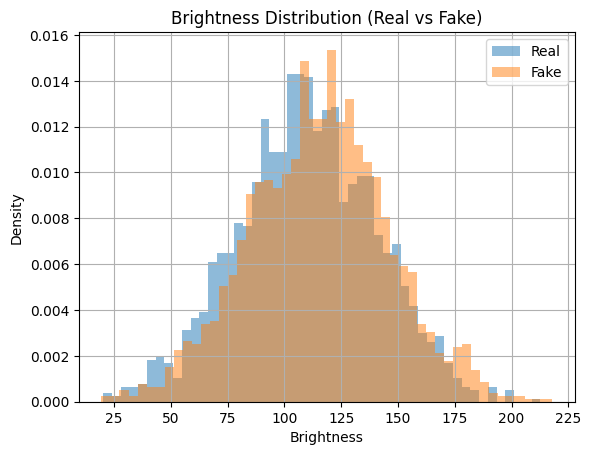

In [8]:
import matplotlib.pyplot as plt

# Extract brightness
real_brightness = [f["brightness"] for f in real_features]
fake_brightness = [f["brightness"] for f in fake_features]

plt.figure()

plt.hist(real_brightness, bins=50, alpha=0.5, label="Real", density=True)
plt.hist(fake_brightness, bins=50, alpha=0.5, label="Fake", density=True)

plt.title("Brightness Distribution (Real vs Fake)")
plt.xlabel("Brightness")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.savefig("brightness_comparison.png")
plt.show()

Blur

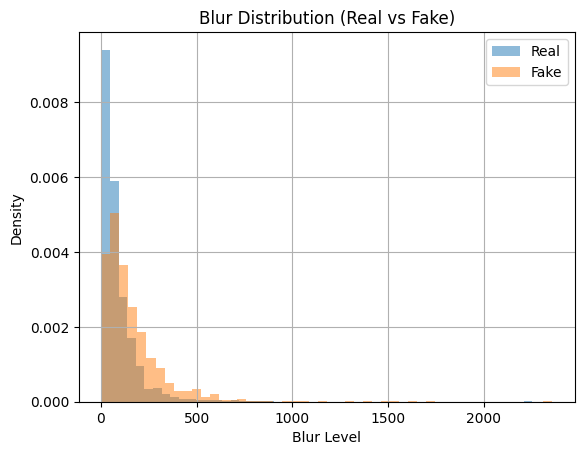

In [9]:
# Extract blur
real_blur = [f["blur"] for f in real_features]
fake_blur = [f["blur"] for f in fake_features]

plt.figure()

plt.hist(real_blur, bins=50, alpha=0.5, label="Real", density=True)
plt.hist(fake_blur, bins=50, alpha=0.5, label="Fake", density=True)

plt.title("Blur Distribution (Real vs Fake)")
plt.xlabel("Blur Level")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.savefig("blur_comparison.png")
plt.show()

In [10]:
import numpy as np

print("----- Brightness -----")
print("Real  -> Mean:", np.mean(real_brightness), " Std:", np.std(real_brightness))
print("Fake  -> Mean:", np.mean(fake_brightness), " Std:", np.std(fake_brightness))

print("\n----- Blur -----")
print("Real  -> Mean:", np.mean(real_blur), " Std:", np.std(real_blur))
print("Fake  -> Mean:", np.mean(fake_blur), " Std:", np.std(fake_blur))

----- Brightness -----
Real  -> Mean: 109.79333602905274  Std: 30.42733972927735
Fake  -> Mean: 115.20090515136718  Std: 30.788805879487843

----- Blur -----
Real  -> Mean: 87.94930648998171  Std: 106.65931934648825
Fake  -> Mean: 163.8517455556821  Std: 171.8703034608049


The brightness distributions of real and fake images are relatively similar, with only a small difference in their average values. This suggests that brightness is not a strong distinguishing feature for detecting deepfake images.

However, there is a significant difference in blur levels between real and fake images. Fake images show a much higher average blur compared to real images. This may be due to artifacts introduced during the deepfake generation process, such as blending, compression, or imperfect face synthesis.

These results indicate that blur is a more informative feature than brightness for distinguishing between real and fake images, and it could be useful for improving model performance.

In [11]:
import cv2
import numpy as np
from collections import Counter

# Face detection function (already used)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def get_faces(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    return faces

Face size

In [12]:
# Collect face sizes (Real vs Fake)

real_face_sizes = []
fake_face_sizes = []

# REAL
for img_name in real_sample:
    img_path = os.path.join(real_path, img_name)
    image = cv2.imread(img_path)

    if image is None:
        continue

    faces = get_faces(image)

    for (x, y, w, h) in faces:
        real_face_sizes.append(w * h)

# FAKE
for img_name in fake_sample:
    img_path = os.path.join(fake_path, img_name)
    image = cv2.imread(img_path)

    if image is None:
        continue

    faces = get_faces(image)

    for (x, y, w, h) in faces:
        fake_face_sizes.append(w * h)

print("Collected real face sizes:", len(real_face_sizes))
print("Collected fake face sizes:", len(fake_face_sizes))

Collected real face sizes: 1234
Collected fake face sizes: 1180


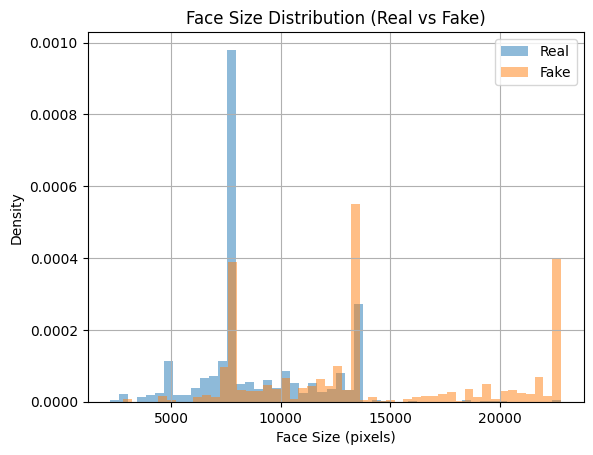

In [13]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(real_face_sizes, bins=50, alpha=0.5, label="Real", density=True)
plt.hist(fake_face_sizes, bins=50, alpha=0.5, label="Fake", density=True)

plt.title("Face Size Distribution (Real vs Fake)")
plt.xlabel("Face Size (pixels)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.savefig("face_size_distribution.png")
plt.show()

In [14]:
import numpy as np

print("----- Face Size -----")
print("Real  -> Mean:", np.mean(real_face_sizes), " Std:", np.std(real_face_sizes))
print("Fake  -> Mean:", np.mean(fake_face_sizes), " Std:", np.std(fake_face_sizes))

----- Face Size -----
Real  -> Mean: 8871.963533225284  Std: 2742.0670883154053
Fake  -> Mean: 14052.522033898305  Std: 5486.1725497950465


Face Size Analysis shows a clear difference between real and fake images.

The average face size in real images is 8,871.96 pixels with a standard deviation of 2,742.07, while fake images have a much larger average face size of 14,052.52 pixels with a higher standard deviation of 5,486.17.

This indicates that fake images tend to contain larger and more variable face regions compared to real images. The higher mean suggests that faces in fake images are generally more zoomed-in or artificially scaled, while the larger standard deviation suggests inconsistent face generation or manipulation across samples.

Overall, face size appears to be a useful feature for distinguishing between real and fake images in this dataset.

In [15]:
def image_quality_check(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return {
            "valid": False,
            "reason": "corrupted image"
        }

    # Resize for consistency
    image = cv2.resize(image, (128, 128))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Feature 1: brightness
    brightness = np.mean(gray)

    # Feature 2: blur
    blur = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Face detection
    faces = get_faces(image)
    face_count = len(faces)

    # Face size inconsistency
    face_sizes = []
    for (x, y, w, h) in faces:
        face_sizes.append(w * h)

    size_variance = np.var(face_sizes) if len(face_sizes) > 1 else 0

    # Output
    return {
        "valid": True,
        "brightness": brightness,
        "blur": blur,
        "face_count": face_count,
        "size_variance": size_variance
    }

# Note:
# Some features are reused in both functions, they serve different purposes:
# - extract_face_features: used for model training
# - image_quality_check: used for dataset quality analysis

real vs fake

In [16]:
import random

# Random sampling
random.seed(42)
limit = 2000

real_sample = random.sample(real_images, limit)
fake_sample = random.sample(fake_images, limit)

# Initialize counters
real_no_face = 0
real_one_face = 0
real_multi_face = 0

fake_no_face = 0
fake_one_face = 0
fake_multi_face = 0

# Process REAL images
for img_name in real_sample:
    img_path = os.path.join(real_path, img_name)

    result = image_quality_check(img_path)

    if not result["valid"]:
        continue

    if result["face_count"] == 0:
        real_no_face += 1
    elif result["face_count"] == 1:
        real_one_face += 1
    else:
        real_multi_face += 1

# Process FAKE images
for img_name in fake_sample:
    img_path = os.path.join(fake_path, img_name)

    result = image_quality_check(img_path)

    if not result["valid"]:
        continue

    if result["face_count"] == 0:
        fake_no_face += 1
    elif result["face_count"] == 1:
        fake_one_face += 1
    else:
        fake_multi_face += 1

# Print results
print("REAL images face distribution:")
print("No face:", real_no_face)
print("One face:", real_one_face)
print("Multiple faces:", real_multi_face)

print("\nFAKE images face distribution:")
print("No face:", fake_no_face)
print("One face:", fake_one_face)
print("Multiple faces:", fake_multi_face)

REAL images face distribution:
No face: 384
One face: 1616
Multiple faces: 0

FAKE images face distribution:
No face: 424
One face: 1574
Multiple faces: 2


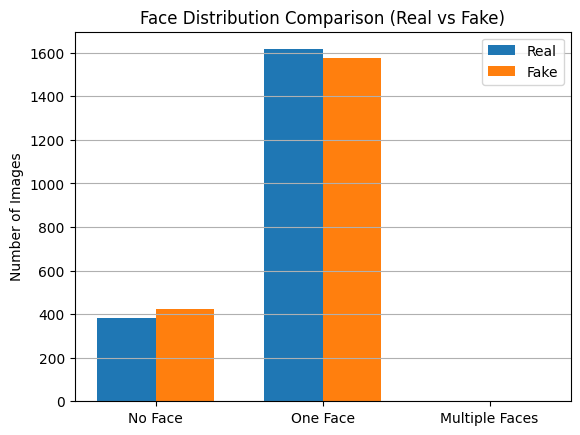

In [17]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["No Face", "One Face", "Multiple Faces"]

real_counts = [real_no_face, real_one_face, real_multi_face]
fake_counts = [fake_no_face, fake_one_face, fake_multi_face]

x = np.arange(len(labels))
width = 0.35

plt.figure()

plt.bar(x - width/2, real_counts, width, label="Real")
plt.bar(x + width/2, fake_counts, width, label="Fake")

plt.xticks(x, labels)
plt.title("Face Distribution Comparison (Real vs Fake)")
plt.ylabel("Number of Images")
plt.legend()
plt.grid(axis='y')

plt.savefig("face_distribution_comparison.png")
plt.show()

Face count distribution does not provide strong discriminative power between real and fake images and is mainly useful for data quality assessment.